In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv('../data/raw/listings_csv.csv')

In [3]:
# Check if rows with missing price also have availability/review patterns

null_price_rows = df[df['price'].isnull()]

print("Null price rows - has_availability value counts:")
print(null_price_rows['has_availability'].value_counts(dropna=False))

print("\nNull price rows - availability_365 stats:")
print(null_price_rows['availability_365'].describe())

print("\nNull price rows - number_of_reviews stats:")
print(null_price_rows['number_of_reviews'].describe())

# Compare against rows where price IS present, for contrast
not_null_price_rows = df[df['price'].notnull()]
print("\n--- For comparison: rows WITH price ---")
print("has_availability value counts:")
print(not_null_price_rows['has_availability'].value_counts(dropna=False))
print("\navailability_365 stats:")
print(not_null_price_rows['availability_365'].describe())

Null price rows - has_availability value counts:
has_availability
t      3853
NaN     136
f         3
Name: count, dtype: int64

Null price rows - availability_365 stats:
count    3992.000000
mean        6.424599
std        39.590333
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       365.000000
Name: availability_365, dtype: float64

Null price rows - number_of_reviews stats:
count    3992.000000
mean       20.368737
std        49.317866
min         0.000000
25%         3.000000
50%         8.000000
75%        20.000000
max       906.000000
Name: number_of_reviews, dtype: float64

--- For comparison: rows WITH price ---
has_availability value counts:
has_availability
t    6228
f     149
Name: count, dtype: int64

availability_365 stats:
count    6377.000000
mean      148.337620
std       118.336229
min         0.000000
25%        33.000000
50%       131.000000
75%       254.000000
max       365.000000
Name: availability_365, dtype: float64


In [4]:
# 1. Columns that are 100% null - carry zero information


df.isnull().sum()[df.isnull().sum() == 10369]

neighborhood_overview           10369
host_since                      10369
host_response_time              10369
host_response_rate              10369
host_acceptance_rate            10369
host_thumbnail_url              10369
host_neighbourhood              10369
host_total_listings_count       10369
host_verifications              10369
neighbourhood                   10369
neighbourhood_group_cleansed    10369
calendar_updated                10369
instant_bookable                10369
dtype: int64

In [5]:
# dropping these 100% null value columns

cols_100pct_null = [
    'neighborhood_overview', 'host_since', 'host_response_time',
    'host_response_rate', 'host_acceptance_rate', 'host_thumbnail_url',
    'host_neighbourhood', 'host_total_listings_count', 'host_verifications',
    'neighbourhood', 'neighbourhood_group_cleansed', 'calendar_updated',
    'instant_bookable'
]

df = df.drop(columns=cols_100pct_null)

In [6]:
df.shape

(10369, 77)

In [7]:
# 2. URLs / scrape metadata - not predictive of price

cols_urls_metadata = [
    'listing_url', 'scrape_id', 'last_scraped', 'source', 'picture_url',
    'host_url', 'host_profile_id', 'host_profile_url', 'host_picture_url',
    'calendar_last_scraped'
]

df = df.drop(columns=cols_urls_metadata)

In [8]:
df.shape

(10369, 67)

In [9]:
# 3. Redundant column - bathrooms_text covers this with fewer nulls

cols_redundant = ['bathrooms']

df = df.drop(columns=cols_redundant)

In [10]:
df.shape

(10369, 66)

In [11]:
# 4. price_quote_* columns - these are live-quote fields tied to availability,
# not the static listing price we're predicting. Keeping them risks data leakage
# (e.g., price_quote_price_per_night could closely mirror our target).

cols_price_quote = [
    'price_quote_checkin_date', 'price_quote_checkout_date',
    'price_quote_total_price', 'price_quote_price_per_night',
    'price_quote_raw'
]

df = df.drop(columns=cols_price_quote)

In [12]:
df.shape

(10369, 61)

In [13]:
# A quick note on the price_quote_* columns — I added them to this drop list even though we didn't discuss them earlier as "useless." My reasoning: they're a live pricing quote, not the listing's static price, and keeping them alongside your actual target (price) risks data leakage — a term worth knowing: it means accidentally including information in your features that wouldn't actually be available at prediction time, which makes your model look better than it really is.

Now Dropping ROWS

Dropping rows with missing price
3,992 of 10,369 listings (38%) have a null price. Investigation showed these listings have a median availability_365 of 0 days, versus 131 days for listings with a price — meaning these are largely inactive/fully-booked listings that Airbnb doesn't generate a live price for. Since our goal is predicting a fair price for a bookable stay, these rows can't meaningfully contribute to that question and are dropped rather than imputed.

In [14]:
before_rows = df.shape[0]

df = df[df['price'].notnull()]

after_rows = df.shape[0]
print(f"Dropped {before_rows - after_rows} rows. New shape: {df.shape}")

Dropped 3992 rows. New shape: (6377, 61)


In [15]:
# Duplicates

print(f"Duplicate rows (all columns identical): {df.duplicated().sum()}")
print(f"Duplicate listing IDs: {df['id'].duplicated().sum()}")

Duplicate rows (all columns identical): 0
Duplicate listing IDs: 0


In [16]:
# Next: clean the price column itself.
# Airbnb data typically stores price as a string like "$120.00" (with a dollar sign and comma for thousands, e.g., "$1,200.00"), which pandas can't do math on. We need to strip those characters and convert it to a proper number.

In [17]:
df['price'].head(10)

0      $94.00
2     $313.67
5     $440.27
6     $574.67
7     $154.06
10    $289.33
12    $269.00
13     $85.59
14    $433.50
16    $373.00
Name: price, dtype: str

In [18]:
# Convert price to a clean numeric column

df['price'] = df['price'].str.replace('$', '', regex=False)
df['price'] = df['price'].str.replace(',', '', regex=False)
df['price'] = df['price'].astype(float)

df['price'].describe()

count     6377.000000
mean       346.621932
std        327.297968
min         14.700000
25%        206.670000
50%        291.000000
75%        411.000000
max      11412.000000
Name: price, dtype: float64

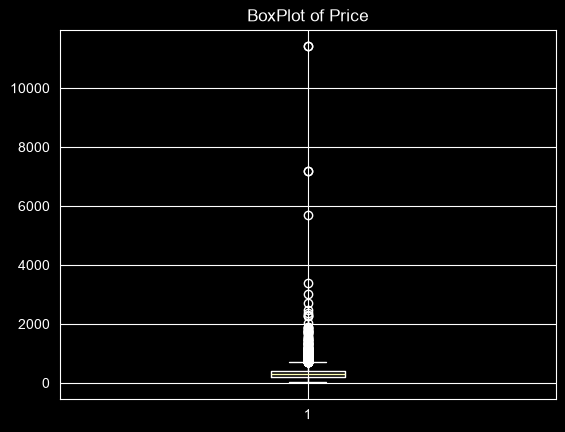

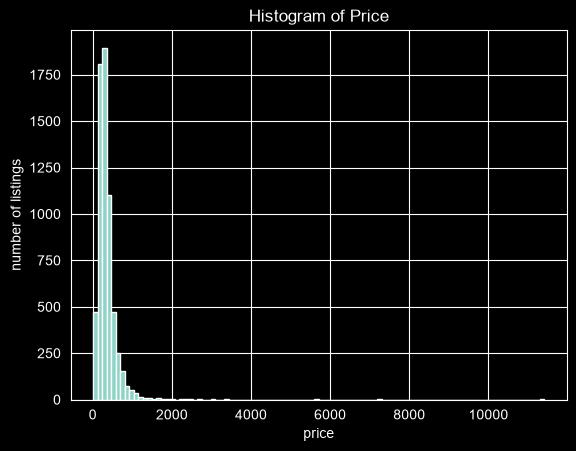

In [19]:
#   BoxPlot of "Price"

plt.boxplot(df['price'])
plt.title("BoxPlot of Price")
plt.show()


# Histogram of "Price"

plt.hist(df['price'], bins= 100)
plt.xlabel("price")
plt.ylabel("number of listings")
plt.title("Histogram of Price")
plt.show()

The boxplot (25th–75th percentile) is tiny and tight — most listings live between €207 and €411. Then there's this enormous gap out to €11,412, which is nowhere near the rest of the data. That gap is the visual proof of what we suspected: a small number of listings are priced in a completely different universe than everything else, almost certainly the "host doesn't want bookings but won't delist" pattern.

In [20]:
#Count how many listings sit above different candidate thresholds (e.g., >€1000, >€2000, >€5000) so we pick a cutoff based on evidence, not a guess

thresholds = [500, 1000, 1500, 2000, 3000, 5000]

for t in thresholds:
    count = (df['price'] > t).sum()
    percent = count / len(df) * 100
    print(f"Listings above €{t}: {count} ({percent:.2f}%)")

Listings above €500: 942 (14.77%)
Listings above €1000: 107 (1.68%)
Listings above €1500: 32 (0.50%)
Listings above €2000: 14 (0.22%)
Listings above €3000: 7 (0.11%)
Listings above €5000: 5 (0.08%)


Good data. Here's how to read it: there's a steep cliff between €500 and €1000 (14.77% → 1.68%), and then it keeps thinning out fast. That drop is the signal — beyond roughly €1000-2000, we're in "rare, unusual" territory rather than "normal high-end listing" territory.

But before picking a round number, there's a smarter check: a €2000/night listing could be completely legitimate if it's a huge house that sleeps 12 people — not every high price is a fake "blocking" listing. We should check that before cutting anything.

In [21]:
# Look at the top 20 most expensive listings - are they big properties, or suspicious?

top_expensive = df.nlargest(20, 'price')[['price', 'accommodates', 'bedrooms', 'room_type', 'availability_365', 'number_of_reviews']]
print(top_expensive)

          price  accommodates  bedrooms        room_type  availability_365  \
9551   11412.00             4       2.0  Entire home/apt               330   
373    11411.80             2       1.0  Entire home/apt               365   
4364    7200.00            16       7.0  Entire home/apt               358   
4499    7200.00            16      17.0  Entire home/apt               358   
3491    5706.00             2       1.0  Entire home/apt               365   
6267    3382.60             8       4.0  Entire home/apt               359   
10292   3025.00             2       1.0  Entire home/apt               362   
10310   2700.00             8       4.0  Entire home/apt                76   
1502    2477.00             4       3.0  Entire home/apt               359   
6350    2354.00             4       3.0  Entire home/apt               121   
10081   2304.40             6       3.0  Entire home/apt               327   
9300    2282.50             4       2.0  Entire home/apt        

Look at the two groups:

Legitimately expensive (big properties):

Rows 4364/4499: €7,200/night, but sleeps 16 people — that's actually only €450/person, totally reasonable for a huge group house
Row 9699: €1,912/night, sleeps 12 — again, reasonable per-person

Looks fake/blocking:

Row 9551: €11,412/night, sleeps only 4, available 330 days a year, but only 1 review — a tiny apartment priced absurdly high, sitting "available" almost the whole year without getting booked. Classic "I don't want bookings but won't delist" pattern.

Row 373: €11,412/night, sleeps only 2, available 365 days, 24 reviews — the reviews are odd here (so it was booked before), but the current price is wildly disconnected from what people were presumably paying to generate those reviews. Likely the host jacked the price up recently to stop new bookings.

In [22]:
# Create a price-per-person column and use that to spot real outliers

df['price_per_person'] = df['price'] / df['accommodates']

df['price_per_person'].describe()

count    6377.000000
mean      120.245639
std       106.412525
min         9.121667
25%        78.455000
50%       108.430000
75%       145.500000
max      5705.900000
Name: price_per_person, dtype: float64

In [23]:
top_pp = df.nlargest(20, 'price_per_person')[['price', 'accommodates', 'bedrooms', 'price_per_person', 'availability_365', 'number_of_reviews']]
print(top_pp)

          price  accommodates  bedrooms  price_per_person  availability_365  \
373    11411.80             2       1.0          5705.900               365   
3491    5706.00             2       1.0          2853.000               365   
9551   11412.00             4       2.0          2853.000               330   
10292   3025.00             2       1.0          1512.500               362   
2527    1712.00             2       1.0           856.000               270   
9884    1562.00             2       1.0           781.000               292   
9883    1487.00             2       1.0           743.500               347   
9250    1333.50             2       NaN           666.750               242   
9882    1301.00             2       1.0           650.500               341   
1502    2477.00             4       3.0           619.250               359   
6350    2354.00             4       3.0           588.500               121   
9300    2282.50             4       2.0           57

Top 9 rows (price per person > €600): almost all have 0 or 1 reviews, and availability near the max (270-365 days) — meaning nobody's booking them, and the price is basically an "invisible fence." Row 373 is the odd one (24 reviews) but as we noted, that's likely a case where the price was jacked up after those reviews happened.

Below €600/person: the pattern flips — row 1502 (€619/person, 27 reviews), row 6350 (€588/person, 15 reviews), row 4124 (€467/person, 53 reviews). These have real booking history, meaning people are actually paying these prices. Amsterdam canal-house apartments can legitimately be this expensive.

So the cutoff sits right around €600/person. That's not a round number pulled from nowhere — it's the point where "no one is booking this" (0-1 reviews) switches to "people are actually paying this" (15+ reviews).

In [24]:
# Check how many rows this actually removes
print(f"Rows above €600/person: {(df['price_per_person'] > 600).sum()}")

before_rows = df.shape[0]
df = df[df['price_per_person'] <= 600]
after_rows = df.shape[0]

print(f"Dropped {before_rows - after_rows} rows. New shape: {df.shape}")

Rows above €600/person: 10
Dropped 10 rows. New shape: (6367, 62)


---------------------------------- DONE WITH THE PRICE -------------------------------------

In [25]:
df['amenities'].head(5).tolist()

['["Heating", "Fire extinguisher", "Hot water", "Refrigerator", "Bed linens", "Private entrance", "Carbon monoxide alarm", "Host greets you", "Smoke alarm", "Hangers", "Shampoo", "Essentials", "Iron", "Hair dryer", "Lock on bedroom door", "Coffee maker", "Wifi", "Cleaning products"]',
 '["Smoking allowed", "Extra pillows and blankets", "Stove", "Heating", "Refrigerator", "Shower gel", "Hair dryer", "Hot water", "Dishes and silverware", "Pets allowed", "Self check-in", "Dishwasher", "Bed linens", "Smoke alarm", "Shampoo", "Laundromat nearby", "Coffee maker: french press", "Lockbox", "Cooking basics", "Paid parking off premises", "Wifi", "Portable fans", "Washer", "Kitchen", "Oven", "Fire extinguisher", "First aid kit", "Freezer", "Iron", "Carbon monoxide alarm", "Hangers", "Essentials"]',
 '["Wine glasses", "Bikes", "Children\\u2019s bikes", "Hangers", "Luggage dropoff allowed", "Outdoor playground", "Housekeeping - available at extra cost", "Freezer", "Children\\u2019s dinnerware", "Ho

Here's the plan: we won't turn this into 200 individual "has_X" columns (way too many, most will be useless). Instead, we'll do two useful things:

Count total amenities per listing — a simple, meaningful number (more amenities generally = higher price potential)
Flag a handful of specific high-value amenities that likely matter for price — things like Wifi, Kitchen, Washer, Air conditioning, Pool, Free parking

In [26]:
# Parse the string into a real Python list

import ast

df['amenities_list'] = df['amenities'].apply(ast.literal_eval)

# Sanity check - look at the first one, now as a real list
print(type(df['amenities_list'].iloc[0]))
print(df['amenities_list'].iloc[0])

<class 'list'>
['Heating', 'Fire extinguisher', 'Hot water', 'Refrigerator', 'Bed linens', 'Private entrance', 'Carbon monoxide alarm', 'Host greets you', 'Smoke alarm', 'Hangers', 'Shampoo', 'Essentials', 'Iron', 'Hair dryer', 'Lock on bedroom door', 'Coffee maker', 'Wifi', 'Cleaning products']


ast.literal_eval --> safely converts a string that looks like Python code (a list, in this case) into the actual Python object — so '["Wifi", "Kitchen"]' (text) becomes ["Wifi", "Kitchen"] (a real list you can measure, search, and count).

In [27]:
# Total amenities count - simple but often a strong price signal
df['amenities_count'] = df['amenities_list'].apply(len)

# Flag specific high-value amenities
key_amenities = ['Wifi', 'Kitchen', 'Washer', 'Air conditioning', 'Free parking', 'Pool', 'Dedicated workspace', 'TV']

for amenity in key_amenities:
    col_name = 'has_' + amenity.lower().replace(' ', '_')
    df[col_name] = df['amenities_list'].apply(lambda x: amenity in x)

# Check results
df[['amenities_count'] + ['has_' + a.lower().replace(' ', '_') for a in key_amenities]].head()

,amenities_count,has_wifi,has_kitchen,has_washer,has_air_conditioning,has_free_parking,has_pool,has_dedicated_workspace,has_tv
0,18,True,False,False,False,False,False,False,False
2,32,True,True,True,False,False,False,False,False
5,52,True,False,False,False,False,False,True,False
6,56,True,True,False,False,False,False,True,False
7,20,True,False,False,False,False,False,False,False


A couple of things to know about this code:

- amenities_count — just the length of each list, giving you a single number per listing.

- For each amenity in key_amenities, we create a new column like has_wifi, has_kitchen, etc. — True/False depending on whether that word appears in the listing's amenity list.

- Note: matching is exact-text, so "Wifi" won't catch something worded slightly differently — good enough for common amenities like these, but worth knowing as a limitation if you ever expand this list

In [28]:
# we can see the number of columns has increased, by performing above cell

df.shape

(6367, 72)

In [29]:
# Drop the now-redundant raw columns

df = df.drop(columns=['amenities', 'amenities_list'])
print(df.shape)

(6367, 70)


We keep the derived features (amenities_count, has_wifi, etc.) but drop the original messy string and the intermediate list — we've already extracted what we need, so there's no reason to carry the raw text forward (it'd just bloat the dataset and confuse a model that can't read strings anyway).

In [30]:
# Check where we stand on nulls now

df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

host_about                     3030
host_location                  1035
bedrooms                        912
beds                            767
review_scores_location          631
first_review                    631
review_scores_value             631
reviews_per_month               631
review_scores_accuracy          631
review_scores_cleanliness       631
review_scores_checkin           631
review_scores_communication     631
review_scores_rating            631
last_review                     631
description                     308
license                         154
host_name                       138
hosts_time_as_user_months       138
host_has_profile_pic            138
host_identity_verified          138
host_listings_count             138
host_is_superhost               138
hosts_time_as_host_months       138
hosts_time_as_host_years        138
hosts_time_as_user_years        138
bathrooms_text                    9
minimum_nights                    3
maximum_maximum_nights      

In [31]:
# Confirm: do these 631 rows all have number_of_reviews == 0?
print(df[df['review_scores_rating'].isnull()]['number_of_reviews'].value_counts())

number_of_reviews
0    631
Name: count, dtype: int64


In [32]:
# Flag: has this listing ever been reviewed?
df['has_reviews'] = df['number_of_reviews'] > 0

# Fill review scores and reviews_per_month with 0 - these listings have no reviews to score
review_cols = ['review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
               'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
               'review_scores_value', 'reviews_per_month']

for col in review_cols:
    df[col] = df[col].fillna(0)

# first_review / last_review are dates with no reviews to reference - drop these two columns
# (we already capture "has reviews" and "number_of_reviews" as better signals)
df = df.drop(columns=['first_review', 'last_review'])

print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

host_about                   3030
host_location                1035
bedrooms                      912
beds                          767
description                   308
license                       154
hosts_time_as_host_months     138
hosts_time_as_host_years      138
hosts_time_as_user_months     138
hosts_time_as_user_years      138
host_name                     138
host_has_profile_pic          138
host_listings_count           138
host_is_superhost             138
host_identity_verified        138
bathrooms_text                  9
maximum_nights                  3
minimum_nights                  3
minimum_minimum_nights          3
maximum_minimum_nights          3
minimum_maximum_nights          3
maximum_maximum_nights          3
dtype: int64


Group 2: Property details — bedrooms, beds, bathrooms_text (912, 767, 9 nulls)

In [33]:
df.groupby('accommodates')[['bedrooms', 'beds']].median()

,bedrooms,beds
accommodates,,
1,1.0,1.0
2,1.0,1.0
3,1.0,2.0
4,2.0,2.0
5,3.0,3.0
6,3.0,4.0
7,3.0,5.0
8,3.0,5.0
9,2.5,7.0


This shows the typical number of bedrooms/beds for each guest capacity — e.g., a 2-person listing typically has 1 bedroom, 1 bed. We'll use this pattern to fill nulls sensibly (a listing that sleeps 6 with a missing bedroom count almost certainly isn't a studio).

In [34]:
# Fill missing bedrooms and beds using this pattern

# Fill missing bedrooms/beds using the median for that accommodates value
df['bedrooms'] = df['bedrooms'].fillna(df.groupby('accommodates')['bedrooms'].transform('median'))
df['beds'] = df['beds'].fillna(df.groupby('accommodates')['beds'].transform('median'))

# Check if any nulls remain (can happen if a rare accommodates value has all-null bedrooms/beds too)
print(df[['bedrooms', 'beds']].isnull().sum())

bedrooms    0
beds        0
dtype: int64


What this does: for each row missing bedrooms, it looks up that row's accommodates value, finds the median bedrooms for other listings with the same accommodates, and fills it in — same for beds. This is smarter than filling with one single global median, because a studio and a 16-person house shouldn't get the same fallback number.

In [35]:
# Quick fix for bathrooms_text (only 9 nulls)

before = df.shape[0]
df = df.dropna(subset=['bathrooms_text'])
print(f"Dropped {before - df.shape[0]} rows. New shape: {df.shape}")

Dropped 9 rows. New shape: (6358, 69)


In [36]:
df[df['host_listings_count'].isnull()][['host_name', 'host_is_superhost', 'number_of_reviews']].head(10)

,host_name,host_is_superhost,number_of_reviews
6620,NaN,NaN,13
6853,NaN,NaN,37
6854,NaN,NaN,141
6855,NaN,NaN,69
6909,NaN,NaN,114
6926,NaN,NaN,7
6927,NaN,NaN,90
6928,NaN,NaN,10
7107,NaN,NaN,333
7114,NaN,NaN,60


Interesting — these aren't low-activity listings we could dismiss. Row 7107 has 333 reviews — clearly a real, well-established, frequently-booked listing. So this isn't "junk data," it's more likely the host deactivated their profile or account while the listing itself stayed live. Dropping these 138 rows would mean throwing away genuinely good price data just because of missing host metadata — not a good trade.

In [37]:
# Fill host-related nulls with sensible defaults + a flag


# Flag that host info is missing (potentially useful signal itself - e.g. "less trustworthy" for a model)
df['host_info_missing'] = df['host_name'].isnull()

# host_is_superhost, host_has_profile_pic, host_identity_verified - fill with False
# (can't verify superhost/verified status if the profile is gone, so False is the safe assumption)
for col in ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified']:
    df[col] = df[col].fillna(False)

# host_listings_count - fill with 1 (assume single-listing host as the safe default)
df['host_listings_count'] = df['host_listings_count'].fillna(1)

# hosts_time_as_user/host years/months - fill with 0 (unknown tenure, treat as no info)
for col in ['hosts_time_as_user_years', 'hosts_time_as_user_months', 'hosts_time_as_host_years', 'hosts_time_as_host_months']:
    df[col] = df[col].fillna(0)

# host_name - fill with 'Unknown' as a placeholder (not used as a model feature anyway, just for readability)
df['host_name'] = df['host_name'].fillna('Unknown')

print(df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False))

host_about                3023
host_location             1030
description                308
license                    154
maximum_nights               2
minimum_nights               2
minimum_minimum_nights       2
maximum_minimum_nights       2
minimum_maximum_nights       2
maximum_maximum_nights       2
dtype: int64


Group 4: Final cleanup

host_about (3,023 nulls, ~47%) — free-text host bio. Too many missing to impute meaningfully, and it's not a strong price driver on its own. We'll just convert it to a simple flag (has_host_about) instead of keeping the raw text.

host_location (1,030 nulls) — same idea, low value for price prediction, we'll flag it or drop it.

description (308 nulls) — low null count, but it's raw text we're not using directly for modeling right now (no NLP planned yet), so we'll just fill blanks with an empty string rather than drop rows.

license (154 nulls) — mostly a legal/registration ID, unlikely to affect price directly. We'll flag presence instead of using the raw value.

minimum_nights/maximum_nights family (2 nulls each, tiny) — just drop these 2 rows.

In [38]:
# host_about, host_location, license -> convert to "has_X" flags instead of keeping raw/messy values
df['has_host_about'] = df['host_about'].notnull()
df['has_host_location'] = df['host_location'].notnull()
df['has_license'] = df['license'].notnull()

df = df.drop(columns=['host_about', 'host_location', 'license'])

# description - just fill blank, not using for modeling yet
df['description'] = df['description'].fillna('')

# minimum/maximum nights family - drop the tiny number of remaining null rows
nights_cols = ['maximum_nights', 'minimum_nights', 'minimum_minimum_nights',
               'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights']
df = df.dropna(subset=nights_cols)

print(f"Final shape: {df.shape}")
print(df.isnull().sum().sum())  # should print 0

Final shape: (6356, 70)
0


In [39]:
df.to_csv('../data/processed/amsterdam_listings_cleaned.csv', index=False)
print(f"Saved {df.shape[0]} rows, {df.shape[1]} columns")

Saved 6356 rows, 70 columns
